In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [16]:
df = pd.read_csv("EV_Data (1).csv")

df = df.dropna()

df['state'] = LabelEncoder().fit_transform(df['state'])

df['Party'] = LabelEncoder().fit_transform(df['Party'])

In [17]:
X = df.drop(columns=['EV Registrations', 'Unnamed: 0.1', 'Unnamed: 0', 'EV Share (%)', 'year'])
y = df['EV Share (%)']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # regression output

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 1.9692 - val_loss: 0.7171
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9770 - val_loss: 0.2782
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5023 - val_loss: 0.1476
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3125 - val_loss: 0.1068
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2101 - val_loss: 0.0833
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1670 - val_loss: 0.0608
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1405 - val_loss: 0.0462
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1213 - val_loss: 0.0401
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1060 - val_loss: 0.0383
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0924 - val_loss: 0.0363
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0811 - val_loss: 0.0342
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0

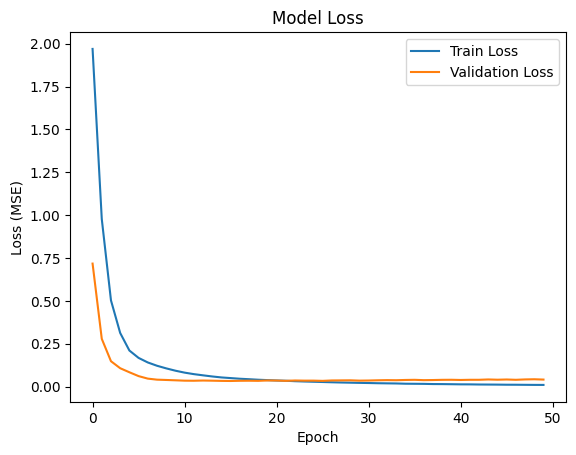

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [22]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

print("R^2:", r2_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
R^2: 0.9076461236204414


In [25]:
model.save("ev_model.keras")